# 1. Import Libs & Settings

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoConfig,
    XLMRobertaPreTrainedModel,
    XLMRobertaModel,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    set_seed
)
from transformers.modeling_outputs import SequenceClassifierOutput

In [2]:
def set_up(seed=42):
  set_seed(seed)
  os.environ["PYTHONHASHSEED"] = str(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

In [3]:
SEED = 42
set_up(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [4]:
TRAIN_DATASET_PATH = "/kaggle/input/datasets/haibuii2006/legalai/train_ver3.csv"
VAL_DATASET_PATH = "/kaggle/input/datasets/haibuii2006/legalai/val_ver3.csv"
TEST_DATASET_PATH = "/kaggle/input/datasets/haibuii2006/legalai/test_ver3.csv"

In [5]:
df_train = pd.read_csv(TRAIN_DATASET_PATH)
df_val = pd.read_csv(VAL_DATASET_PATH)
df_test = pd.read_csv(TEST_DATASET_PATH)

In [ ]:
TARGET_SAMPLES = 3000
MAX_SAMPLES_CLASS_0 = 4500

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = 'BAAI/bge-reranker-v2-m3'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

nice_class_map = {
    1: "Chemicals, Industry, Science, Photography",
    2: "Paints, Varnishes, Lacquers, Preservatives",
    3: "Cosmetics, Soaps, Perfumery, Cleaning preparations",
    4: "Industrial oils, Greases, Fuels, Candles",
    5: "Pharmaceuticals, Medical, Hygiene, Dietetic food",
    6: "Common metals, Hardware, Metal building materials",
    7: "Machines, Motors, Engines, Tools",
    8: "Hand tools, Cutlery, Side arms, Razors",
    9: "Electronics, Computers, Software, Scientific instruments, Mobile phones",
    10: "Medical devices, Surgical instruments, Orthopedic",
    11: "Lighting, Heating, Cooling, Cooking appliances",
    12: "Vehicles, Transport apparatus, Cars, Bikes",
    13: "Firearms, Ammunition, Explosives",
    14: "Jewelry, Watches, Precious metals, Gemstones",
    15: "Musical instruments",
    16: "Paper, Printed matter, Stationery, Office requisites",
    17: "Rubber, Plastics, Insulation materials",
    18: "Leather, Bags, Wallets, Umbrellas",
    19: "Building materials (Non-metallic), Asphalt, Cement",
    20: "Furniture, Mirrors, Picture frames",
    21: "Household utensils, Kitchenware, Glassware, Combs",
    22: "Ropes, Strings, Nets, Tents, Sacks",
    23: "Yarns, Threads for textile",
    24: "Textiles, Bed covers, Table covers, Fabrics",
    25: "Clothing, Footwear, Headgear, Fashion",
    26: "Lace, Embroidery, Ribbons, Buttons",
    27: "Carpets, Rugs, Mats, Floor coverings",
    28: "Games, Toys, Sports equipment",
    29: "Meat, Fish, Poultry, Processed fruits & vegetables",
    30: "Coffee, Tea, Bread, Rice, Sweets, Spices",
    31: "Agricultural products, Fresh fruits, Vegetables, Seeds",
    32: "Beers, Mineral waters, Non-alcoholic drinks",
    33: "Alcoholic beverages (except beer), Wines, Spirits",
    34: "Tobacco, Smokers' articles, Matches",
    35: "Advertising, Business management, Retail services, Marketing",
    36: "Insurance, Financial affairs, Real estate, Banking",
    37: "Building construction, Repair, Installation services",
    38: "Telecommunications, Broadcasting",
    39: "Transport, Packaging, Storage of goods, Travel",
    40: "Treatment of materials, Recycling, Manufacturing services",
    41: "Education, Training, Entertainment, Sporting activities",
    42: "Technology services, Software development, IT consulting",
    43: "Food and drink services, Restaurants, Hotels",
    44: "Medical services, Hygiene, Beauty care (Spa/Salon)",
    45: "Legal services, Security services, Social services"
}

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

# 2. Preprocessing

In [7]:
all_classes = sorted(list(set(
    df_train["Class 1"].tolist() + df_train["Class 2"].tolist() +
    df_val["Class 1"].tolist() + df_val["Class 2"].tolist() +
    df_test["Class 1"].tolist() + df_test["Class 2"].tolist()
)))

special_tokens_list = [f"[CLASS_{c}]" for c in all_classes]
class_to_token = {c: f"[CLASS_{c}]" for c in all_classes}
class_to_id = {c: i for i, c in enumerate(all_classes)}
NUM_PRODUCT_CLASSES = len(all_classes)

print(f"Total Product Classes: {NUM_PRODUCT_CLASSES}")
print(f"Sample Special Tokens: {special_tokens_list}")

Total Product Classes: 45
Sample Special Tokens: ['[CLASS_1]', '[CLASS_2]', '[CLASS_3]', '[CLASS_4]', '[CLASS_5]', '[CLASS_6]', '[CLASS_7]', '[CLASS_8]', '[CLASS_9]', '[CLASS_10]', '[CLASS_11]', '[CLASS_12]', '[CLASS_13]', '[CLASS_14]', '[CLASS_15]', '[CLASS_16]', '[CLASS_17]', '[CLASS_18]', '[CLASS_19]', '[CLASS_20]', '[CLASS_21]', '[CLASS_22]', '[CLASS_23]', '[CLASS_24]', '[CLASS_25]', '[CLASS_26]', '[CLASS_27]', '[CLASS_28]', '[CLASS_29]', '[CLASS_30]', '[CLASS_31]', '[CLASS_32]', '[CLASS_33]', '[CLASS_34]', '[CLASS_35]', '[CLASS_36]', '[CLASS_37]', '[CLASS_38]', '[CLASS_39]', '[CLASS_40]', '[CLASS_41]', '[CLASS_42]', '[CLASS_43]', '[CLASS_44]', '[CLASS_45]']


In [8]:
def create_structured_text_enhanced(term, nature, purpose, class_id):
  text = str(term).strip()
  context_parts = []
  if nature and str(nature).strip():
    context_parts.append(f"Nature: {str(nature).strip()}")
  if purpose and str(purpose).strip():
    context_parts.append(f"Use: {str(purpose).strip()}")
  if class_id:
    try:
      c_id = int(str(class_id))
      class_desc = nice_class_map.get(c_id, "")
      if class_desc:
        context_parts.append(f"Category: {class_desc}")
    except:
      pass
  if context_parts:
    full_text = f"{text} [ {' | '.join(context_parts)} ]"
  else:
    full_text = text
  return full_text

In [9]:
def preprocess(df):
  label_mapping = {
    'Dissimilar': 0,
    'Low similar': 1,
    'Similar': 2,
    'High similar': 3,
    'Identical': 4
  }
  df['label_score'] = df['Similarity'].map(label_mapping)
  df = df.dropna(subset=['label_score'])
  df['label_score'] = df['label_score'].astype(int)

  df['input_text_1'] = df.apply(
      lambda x: create_structured_text_enhanced(x['Term 1'], x['Nature 1'], x['Purpose 1'], x['Class 1']),
      axis=1
  )

  df['input_text_2'] = df.apply(
      lambda x: create_structured_text_enhanced(x['Term 2'], x['Nature 2'], x['Purpose 2'], x['Class 2']),
      axis=1
  )
  return df

In [10]:
df_train = preprocess(df_train)
df_val = preprocess(df_val)
df_test = preprocess(df_test)

 2.1 Data Rebalance

In [ ]:
df_0 = df_train[df_train['label_score'] == 0]
df_1 = df_train[df_train['label_score'] == 1]
df_2 = df_train[df_train['label_score'] == 2]
df_3 = df_train[df_train['label_score'] == 3]
df_4 = df_train[df_train['label_score'] == 4]

In [ ]:
def calculate_jaccard(text1, text2):
    set1 = set(str(text1).lower().split())
    set2 = set(str(text2).lower().split())
    if len(set1) == 0 or len(set2) == 0: return 0.0
    intersection = len(set1.intersection(set2))
    union = len(set1) + len(set2) - intersection
    return intersection / union

In [ ]:
def augment_cross_pairing(df_input, target_labels=[3, 4]):
      # A , B high similar/ identical, B , C : high similar/ identical => A/C : high similar/identical
      df = df_input.copy()
      df['key_1'] = df['Class 1'].astype(str) + " | " + df['Term 1'].astype(str)
      df['key_2'] = df['Class 2'].astype(str) + " | " + df['Term 2'].astype(str)
      high_quality_df = df[df['label_score'].isin(target_labels)].copy()

      forward = high_quality_df[['key_1', 'key_2', 'label_score', 'Class 2', 'Term 2']].rename(
          columns={'key_1': 'parent', 'key_2': 'child', 'label_score': 'score', 'Class 2': 'class_child', 'Term 2': 'term_child'}
        )
      backward = high_quality_df[['key_2', 'key_1', 'label_score', 'Class 1', 'Term 1']].rename(
          columns={'key_2': 'parent', 'key_1': 'child', 'label_score': 'score', 'Class 1': 'class_child', 'Term 1': 'term_child'}
        )
      connections = pd.concat([forward, backward])

      merged = pd.merge(connections, connections, on='parent', suffixes=('_1', '_2'))
      new_pairs = merged[merged['child_1'] < merged['child_2']].copy()
      if len(new_pairs) == 0:
        return df_input
      new_pairs['label_score'] = new_pairs[['score_1', 'score_2']].min(axis=1)

      df_aug = pd.DataFrame({
            "Class 1": new_pairs["class_child_1"],
            "Term 1": new_pairs["term_child_1"],
            "Class 2": new_pairs['class_child_2'],
            "Term 2": new_pairs['term_child_2'],
            "label_score": new_pairs["label_score"],
            "input_text_1": new_pairs['class_child_1'].astype(str) + ": " + new_pairs['term_child_1'].astype(str),
            "input_text_2": new_pairs['class_child_2'].astype(str) + ": " + new_pairs['term_child_2'].astype(str)
        })

      existing_pairs = set(df['key_1'] + "_" + df['key_2']) | set(df['key_2'] + "_" + df['key_1'])
      df_aug['pair_id'] = df_aug['Class 1'].astype(str) + " | " + df_aug['Term 1'].astype(str) + "_" + \
                          df_aug['Class 2'].astype(str) + " | " + df_aug['Term 2'].astype(str)
      df_aug = df_aug[~df_aug['pair_id'].isin(existing_pairs)]
      df_aug = df_aug.drop(columns=['pair_id'])
      print(f"Number of cross_pairing: {len(df_aug)}")
      return pd.concat([df_input, df_aug], ignore_index=True)

In [ ]:
def augment_and_balance(df_sub, target_count):
    # Đảo chiều (Symmetry) - A vs B thành B vs A
    df_flipped = df_sub.copy()
    df_flipped['input_text_1'] = df_sub['input_text_2']
    df_flipped['input_text_2'] = df_sub['input_text_1']

    df_aug = pd.concat([df_sub, df_flipped])

    current_count = len(df_aug)
    if current_count < target_count:
        df_final = resample(df_aug, replace=True, n_samples=target_count, random_state=42)
    elif current_count > target_count:
        df_final = resample(df_aug, replace=False, n_samples=target_count, random_state=42)
    else:
        df_final = df_aug

    return df_final

In [ ]:
df_0['jaccard'] = df_0.apply(lambda x: calculate_jaccard(x['Term 1'], x['Term 2']), axis=1)
hard_negatives = df_0[df_0['jaccard'] > 0]
easy_negatives = df_0[df_0['jaccard'] == 0]
n_easy_keep = max(0, MAX_SAMPLES_CLASS_0 - len(hard_negatives))
if len(easy_negatives) > n_easy_keep:
    easy_negatives_sampled = resample(easy_negatives, replace=False, n_samples=n_easy_keep, random_state=42)
else:
    easy_negatives_sampled = easy_negatives
df_0_final = pd.concat([hard_negatives, easy_negatives_sampled])
df_0_final = resample(df_0_final, replace=False, n_samples=MAX_SAMPLES_CLASS_0, random_state=42)

In [ ]:
df_aug_full = augment_cross_pairing(df_train)
df_aug_clean = df_aug_full.drop_duplicates(subset=['input_text_1', 'input_text_2'], keep='first')
df_train = df_aug_clean.copy()
df_1_final = augment_and_balance(df_train[df_train['label_score'] == 1], TARGET_SAMPLES)
df_3_final = augment_and_balance(df_train[df_train['label_score'] == 3], TARGET_SAMPLES)
df_2_sub = df_train[df_train['label_score'] == 2]
df_2_final = resample(df_2_sub, replace=(len(df_2_sub) < TARGET_SAMPLES), n_samples=TARGET_SAMPLES, random_state=42)

df_4_sub = df_train[df_train['label_score'] == 4]
df_4_final = resample(df_4_sub, replace=False, n_samples=TARGET_SAMPLES, random_state=42)
df_train_balanced = pd.concat([df_0_final, df_1_final, df_2_final, df_3_final, df_4_final])
df_train_balanced = df_train_balanced.sample(frac=1, random_state=42).reset_index(drop=True) # Shuffle


2.2 Data Loader

In [11]:
def create_dataset(df):
    new_rows = []
    mask_token = tokenizer.mask_token

    for _, row in df.iterrows():
        c1, t1 = row["Class 1"], row["input_text_1"]
        c2, t2 = row["Class 2"], row["input_text_2"]
        label = row["label_score"]

        text1_a = f"{mask_token} {t1}"
        text2_a = f"{class_to_token.get(c2, '')} {t2}"
        label_aux_a = class_to_id.get(c1, 0)

        new_rows.append({
            "text1": text1_a, "text2": text2_a,
            "labels": label, "aux_labels": label_aux_a
        })

        text1_b = f"{class_to_token.get(c1, '')} {t1}"
        text2_b = f"{mask_token} {t2}"
        label_aux_b = class_to_id.get(c2, 0)

        new_rows.append({
            "text1": text1_b, "text2": text2_b,
            "labels": label, "aux_labels": label_aux_b
        })

    return pd.DataFrame(new_rows)

In [12]:
df_train_aug = create_dataset(df_train)
df_val_aug = create_dataset(df_val)
df_test_aug = create_dataset(df_test)

In [14]:
def preprocess_dataset(examples):
    tokenized = tokenizer(
        examples["text1"],
        examples["text2"],
        truncation=True,
        max_length=192,
        padding=False
    )
    tokenized["labels"] = examples["labels"]
    tokenized["aux_labels"] = examples["aux_labels"]
    return tokenized

In [15]:
cols_to_remove = df_train_aug.columns.tolist()

train_ds = Dataset.from_pandas(df_train_aug).map(
    preprocess_dataset,
    batched=True,
    remove_columns=cols_to_remove
)

val_ds = Dataset.from_pandas(df_val_aug).map(
    preprocess_dataset,
    batched=True,
    remove_columns=df_val_aug.columns.tolist()
)

test_ds = Dataset.from_pandas(df_test_aug).map(
    preprocess_dataset,
    batched=True,
    remove_columns=df_test_aug.columns.tolist()
)
cols = ["input_ids", "attention_mask", "labels", "aux_labels"]
for ds in [train_ds, val_ds, test_ds]:
    ds.set_format(type="torch", columns=cols)

Map:   0%|          | 0/29890 [00:00<?, ? examples/s]

Map:   0%|          | 0/4274 [00:00<?, ? examples/s]

Map:   0%|          | 0/8534 [00:00<?, ? examples/s]

# 3. Model

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RankAwareFocalLoss(nn.Module):
    def __init__(self, num_classes=5, gamma=2.0, alpha=0.5):
        """
        Args:
            num_classes (int): Số lượng class (0 -> 4 tức là 5 classes).
            gamma (float): Tham số tập trung mẫu khó cho Focal Loss.
            alpha (float): Trọng số để cân bằng phần phạt khoảng cách Rank (MSE).
        """
        super(RankAwareFocalLoss, self).__init__()
        self.num_classes = num_classes
        self.gamma = gamma
        self.alpha = alpha
        self.register_buffer('rank_values', torch.arange(num_classes).float())

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        focal_loss = focal_loss.mean()
        probs = F.softmax(logits, dim=-1)

        rank_values = self.rank_values.to(logits.device)
        expected_ranks = torch.sum(probs * rank_values, dim=-1)

        rank_loss = F.mse_loss(expected_ranks, targets.float())

        total_loss = focal_loss + (self.alpha * rank_loss)

        return total_loss

In [17]:
from transformers.modeling_outputs import SequenceClassifierOutput
import torch
import torch.nn as nn

class JointClassSimBGE(XLMRobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = 5
        self.num_product_classes = config.num_product_classes

        self.mask_token_id = getattr(config, "mask_token_id", 250001)

        self.roberta = XLMRobertaModel(config)
        self.classifier = nn.Linear(config.hidden_size, self.num_labels)
        self.aux_classifier = nn.Linear(config.hidden_size, self.num_product_classes)

        self.register_buffer("class_weights", None)

        if getattr(config, "gradient_checkpointing", False):
            self.roberta.gradient_checkpointing = True
            self.roberta.config.use_cache = False

        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None,
                labels=None, aux_labels=None,
                num_items_in_batch=None,
                **kwargs):

        outputs = self.roberta(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, **kwargs)

        cls_output = outputs.last_hidden_state[:, 0, :]
        logits_sim = self.classifier(cls_output)

        is_mask_token = (input_ids == self.mask_token_id).int()
        mask_positions = is_mask_token.argmax(dim=-1)

        batch_size = input_ids.size(0)
        batch_indices = torch.arange(batch_size, device=input_ids.device)
        mask_output = outputs.last_hidden_state[batch_indices, mask_positions, :]

        logits_aux = self.aux_classifier(mask_output)

        loss = None
        if labels is not None:
            loss_fct_sim = RankAwareFocalLoss(num_classes=self.num_labels, gamma=2.0, alpha=0.5)
            loss_sim = loss_fct_sim(logits_sim.view(-1, self.num_labels), labels.view(-1))

            loss_aux = torch.tensor(0.0).to(logits_sim.device)

            if aux_labels is not None and self.training:
                loss_fct_aux = nn.CrossEntropyLoss()
                loss_aux = loss_fct_aux(logits_aux.view(-1, self.num_product_classes), aux_labels.view(-1))

            loss = loss_sim + 0.3 * loss_aux

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits_sim
        )

In [18]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, mean_absolute_error

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    if isinstance(labels, tuple):
        labels = labels[0]

    if isinstance(logits, tuple):
        logits = logits[0]

    preds = np.argmax(logits, axis=-1)

    qwk = cohen_kappa_score(labels, preds, weights="quadratic")
    mae = mean_absolute_error(labels, preds)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "qwk": qwk,
        "mae": mae
    }

In [19]:
training_args = TrainingArguments(
    output_dir="./bge_joint_class_sim",
    learning_rate=1.5e-5,
    num_train_epochs=10,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    dataloader_num_workers=2,
    per_device_eval_batch_size=16,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    logging_steps=10,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    data_seed=SEED,
    remove_unused_columns=False
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [20]:
config = AutoConfig.from_pretrained(MODEL_NAME)
config.num_labels = 5
config.num_product_classes = NUM_PRODUCT_CLASSES

model = JointClassSimBGE.from_pretrained(
    MODEL_NAME,
    config=config,
    ignore_mismatched_sizes=True
)
model.resize_token_embeddings(len(tokenizer))
model = model.to(DEVICE)

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

JointClassSimBGE LOAD REPORT from: BAAI/bge-reranker-v2-m3
Key                         | Status     | 
----------------------------+------------+-
classifier.dense.bias       | UNEXPECTED | 
classifier.out_proj.weight  | UNEXPECTED | 
classifier.dense.weight     | UNEXPECTED | 
classifier.out_proj.bias    | UNEXPECTED | 
roberta.pooler.dense.bias   | MISSING    | 
aux_classifier.bias         | MISSING    | 
roberta.pooler.dense.weight | MISSING    | 
classifier.bias             | MISSING    | 
aux_classifier.weight       | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)

print("Bắt đầu Training...")
trainer.train()

Bắt đầu Training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Qwk,Mae
1,2.267680,0.473459,0.851193,0.539817,0.906580,0.267899
2,0.823878,0.356541,0.893074,0.695001,0.934618,0.185073
3,0.466273,0.358251,0.914600,0.788637,0.946131,0.151848
4,0.384183,0.410768,0.911558,0.775632,0.947572,0.150912
5,0.148489,0.462694,0.915068,0.796928,0.945589,0.151848
6,0.023350,0.515780,0.918109,0.806486,0.949190,0.143425
7,0.009485,0.518601,0.923023,0.814052,0.952794,0.133131
8,0.000248,0.535941,0.922789,0.814104,0.951087,0.135470
9,0.001830,0.543200,0.923959,0.816582,0.951154,0.134768
10,0.001031,0.544117,0.924427,0.818487,0.951518,0.133832


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=9350, training_loss=0.8055282591852698, metrics={'train_runtime': 10438.7275, 'train_samples_per_second': 28.634, 'train_steps_per_second': 0.896, 'total_flos': 6.995140121302238e+16, 'train_loss': 0.8055282591852698, 'epoch': 10.0})

# 4. Inference & Analysis

In [22]:
test_output = trainer.predict(test_ds)
predictions = test_output.predictions

if isinstance(predictions, tuple):
    predictions = predictions[0]

reshaped_logits = predictions.reshape(-1, 2, 5)
avg_logits = reshaped_logits.mean(axis=1)

test_preds = np.argmax(avg_logits, axis=-1)
test_true = df_test["label_score"].values

In [23]:
import numpy as np
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
def safe_div(a, b):
    return float(a) / float(b) if b else 0.0

def main(df):
    y_true = df["label"].to_numpy()
    y_pred = df["pred"].to_numpy()

    labels = list(range(5))
    label_names = ['Dissimilar (0)', 'Low (1)', 'Similar (2)', 'High (3)', 'Identical (4)']
    K = len(labels)
    idx = {c: i for i, c in enumerate(labels)}

    cm = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        if t in idx and p in idx:
            cm[idx[t], idx[p]] += 1

    TP = np.diag(cm)
    FP = cm.sum(axis=0) - TP
    FN = cm.sum(axis=1) - TP
    TN = cm.sum() - (TP + FP + FN)

    per_class = []
    for i, c in enumerate(labels):
        support = cm[i, :].sum()
        precision = safe_div(TP[i], TP[i] + FP[i])
        recall = safe_div(TP[i], TP[i] + FN[i])
        f1 = safe_div(2 * precision * recall, precision + recall)
        acc = safe_div(TP[i] + TN[i], TP[i] + TN[i] + FP[i] + FN[i])
        per_class.append({
            "class": c,
            "support": int(support),
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    TP_micro = TP.sum()
    FP_micro = FP.sum()
    FN_micro = FN.sum()

    micro_precision = safe_div(TP_micro, TP_micro + FP_micro)
    micro_recall = safe_div(TP_micro, TP_micro + FN_micro)
    micro_f1 = safe_div(2 * micro_precision * micro_recall, micro_precision + micro_recall)

    macro_precision = np.mean([r["precision"] for r in per_class])
    macro_recall = np.mean([r["recall"] for r in per_class])
    macro_f1 = np.mean([r["f1"] for r in per_class])

    overall_acc = safe_div((y_true == y_pred).sum(), len(y_true))

    mae = np.mean(np.abs(y_true - y_pred))

    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')

    print("Per-class metrics (class | support | accuracy | precision | recall | f1):")
    for r in per_class:
        print(f"{r['class']:>2} | {r['support']:>6} | {r['accuracy']:.4f} | {r['precision']:.4f} | {r['recall']:.4f} | {r['f1']:.4f}")

    print("\nOverall accuracy:", f"{overall_acc:.4f}")
    print("Micro Precision | Recall | F1:", f"{micro_precision:.4f}", f"{micro_recall:.4f}", f"{micro_f1:.4f}")
    print("Macro Precision | Recall | F1:", f"{macro_precision:.4f}", f"{macro_recall:.4f}", f"{macro_f1:.4f}")

    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Quadratic Weighted Kappa (QWK): {qwk:.4f}")
    print("\nConfusion Matrix (Hàng = Thực tế, Cột = Dự đoán):")
    header = "    " + "".join([f" P{c:>3}" for c in labels])
    print(header)
    print("   " + "-" * len(header))
    for i, row in enumerate(cm):
        print(f"T{labels[i]} |" + "".join([f"{val:>4}" for val in row]))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names,
                yticklabels=label_names)

    plt.savefig('confusion_matrix.pdf', format='pdf', bbox_inches='tight')

    plt.savefig('confusion_matrix.png', format='png', dpi=300, bbox_inches='tight')

    plt.show()
    return overall_acc, mae, qwk

In [24]:
result_df = pd.DataFrame({
    "label": test_true,
    "pred": test_preds,
})

Per-class metrics (class | support | accuracy | precision | recall | f1):
 0 |   2360 | 0.9639 | 0.9666 | 0.9682 | 0.9674
 1 |    161 | 0.9756 | 0.6647 | 0.7143 | 0.6886
 2 |    544 | 0.9438 | 0.7754 | 0.7868 | 0.7810
 3 |     77 | 0.9862 | 0.6184 | 0.6104 | 0.6144
 4 |   1125 | 0.9707 | 0.9537 | 0.9342 | 0.9439

Overall accuracy: 0.9201
Micro Precision | Recall | F1: 0.9201 0.9201 0.9201
Macro Precision | Recall | F1: 0.7958 0.8028 0.7991
Mean Absolute Error (MAE): 0.1333
Quadratic Weighted Kappa (QWK): 0.9551

Confusion Matrix (Hàng = Thực tế, Cột = Dự đoán):
     P  0 P  1 P  2 P  3 P  4
   -----------------------------
T0 |2285  26  40   4   5
T1 |  26 115  18   1   1
T2 |  41  30 428  10  35
T3 |   3   0  17  47  10
T4 |   9   2  49  141051


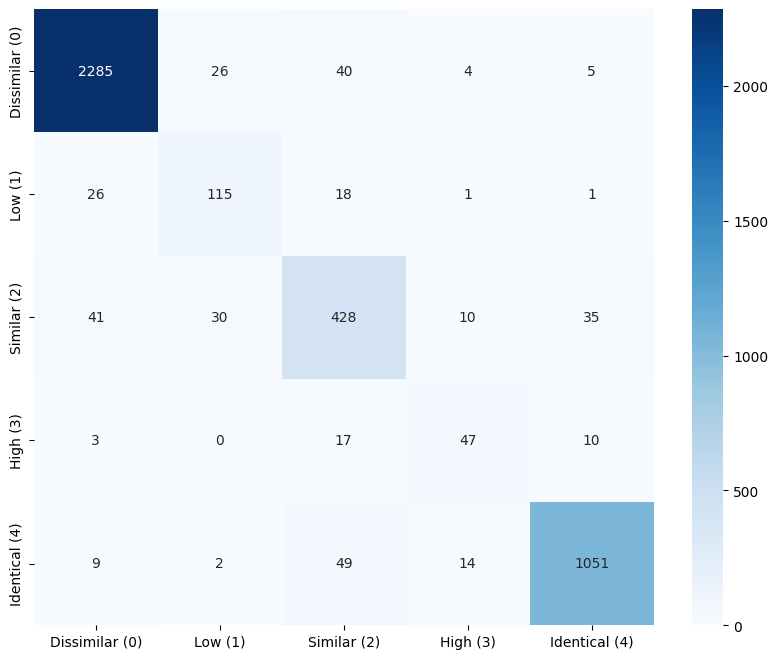

(0.9200843684087181,
 np.float64(0.13334895711272557),
 np.float64(0.9551154416083931))

In [25]:
main(result_df)